In [ ]:
pip install openpyxl
pip install pandas
pip install seaborn

SyntaxError: invalid syntax (4187302547.py, line 1)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [10]:
df = pd.read_excel("Datos/BD_IPSA_1940.xlsx")

In [11]:
display(df.head())

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   object 
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   object 
 5   variedad        2187 non-null   object 
 6   madurada        2187 non-null   object 
 7   producto        2187 non-null   object 
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  TCH             2187 non-null   i

In [13]:
print(df.describe())

        Unnamed: 0           FAZ     dosismad      semsmad         edad  \
count  2187.000000   2187.000000  2187.000000  2187.000000  2187.000000   
mean   2126.506630  80588.332876     0.993278     9.164838    12.766118   
std    1228.561661    572.818299     0.309096     3.441579     1.117866   
min      11.000000  80100.000000     0.000000    -1.600000    10.300000   
25%    1038.000000  80222.000000     0.800000     7.100000    12.000000   
50%    2219.000000  80396.000000     1.000000     8.700000    12.500000   
75%    3223.500000  80660.000000     1.200000    10.600000    13.300000   
max    4222.000000  82519.000000     9.000000    45.000000    21.100000   

            cortes           me        vejez     sacarosa          mes  \
count  2187.000000  2187.000000  2187.000000  2187.000000  2187.000000   
mean      2.794239     9.197759     4.172154    12.777732     6.758573   
std       1.621195     1.574409     6.339255     0.854397     3.482444   
min       1.000000     3.400

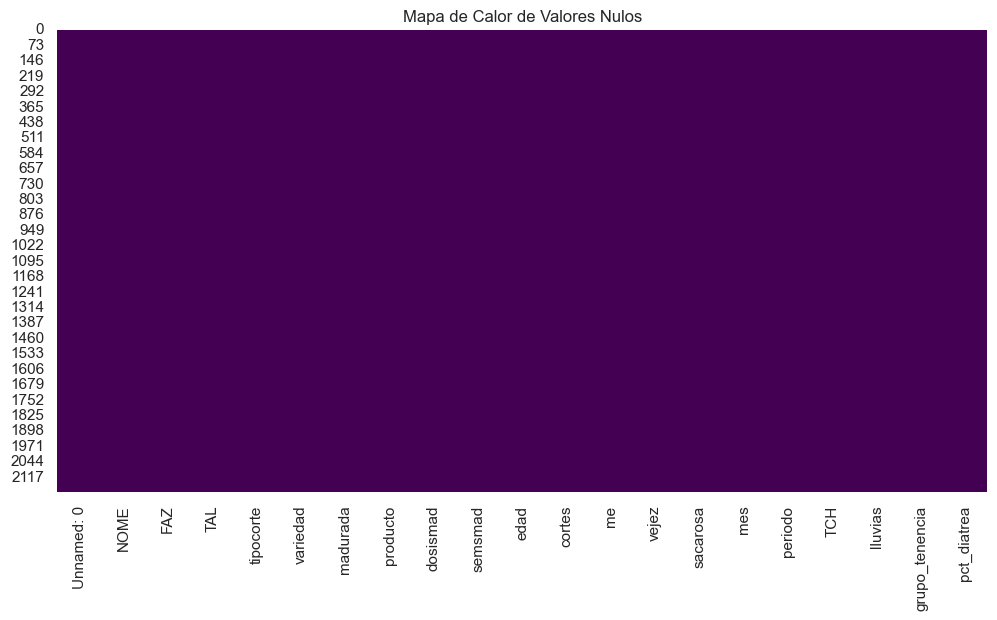

Unnamed: 0        0.0
NOME              0.0
FAZ               0.0
TAL               0.0
tipocorte         0.0
variedad          0.0
madurada          0.0
producto          0.0
dosismad          0.0
semsmad           0.0
edad              0.0
cortes            0.0
me                0.0
vejez             0.0
sacarosa          0.0
mes               0.0
periodo           0.0
TCH               0.0
lluvias           0.0
grupo_tenencia    0.0
pct_diatrea       0.0
dtype: float64

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Calor de Valores Nulos")
plt.show()

# Porcentaje de nulos
faltantes = df.isnull().mean().sort_values(ascending=False) * 100
display(faltantes)

In [15]:
columnas_a_eliminar = faltantes[faltantes > 40].index
df = df.drop(columns=columnas_a_eliminar)
print(f"Columnas eliminadas: {list(columnas_a_eliminar)}")

Columnas eliminadas: []


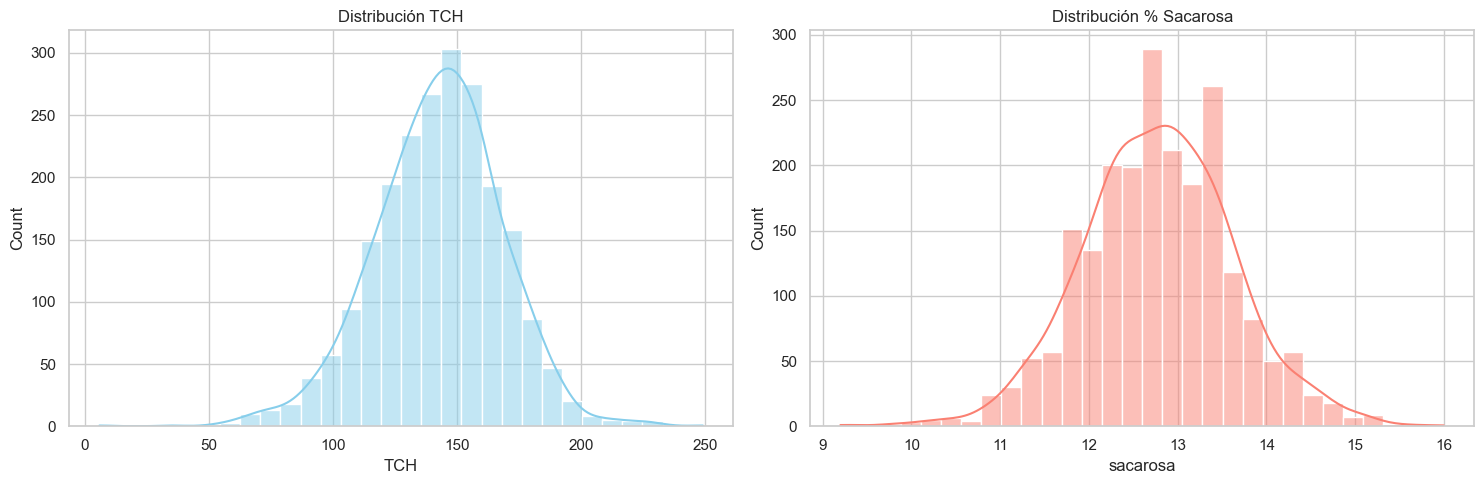

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['TCH'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución TCH')

sns.histplot(df['sacarosa'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución % Sacarosa')

plt.tight_layout()
plt.show()


In [17]:
# Umbrales para TCH
q_tch = np.percentile(df['TCH'], [33.3, 66.6])
print(f"Umbrales TCH -> Bajo: <= {q_tch[0]:.2f}, Medio: <= {q_tch[1]:.2f}, Alto: > {q_tch[1]:.2f}")

# Umbrales para sacarosa
q_sac = np.percentile(df['sacarosa'], [33.3, 66.6])
print(f"Umbrales Sacarosa -> Bajo: <= {q_sac[0]:.2f}, Medio: <= {q_sac[1]:.2f}, Alto: > {q_sac[1]:.2f}")

Umbrales TCH -> Bajo: <= 133.00, Medio: <= 153.00, Alto: > 153.00
Umbrales Sacarosa -> Bajo: <= 12.40, Medio: <= 13.10, Alto: > 13.10


In [18]:
def categorizar_tch(valor):
    if valor <= q_tch[0]:
        return 'Bajo'
    elif valor <= q_tch[1]:
        return 'Medio'
    else:
        return 'Alto'

def categorizar_sacarosa(valor):
    if valor <= q_sac[0]:
        return 'Bajo'
    elif valor <= q_sac[1]:
        return 'Medio'
    else:
        return 'Alto'

In [19]:
df['Categoria_TCH'] = df['TCH'].apply(categorizar_tch)
df['Categoria_Sacarosa'] = df['sacarosa'].apply(categorizar_sacarosa)

df[['TCH', 'Categoria_TCH', 'sacarosa', 'Categoria_Sacarosa']].head()

,TCH,Categoria_TCH,sacarosa,Categoria_Sacarosa
0,112,Bajo,14.0,Alto
1,157,Alto,13.0,Medio
2,167,Alto,13.3,Alto
3,156,Alto,13.4,Alto
4,151,Medio,14.0,Alto


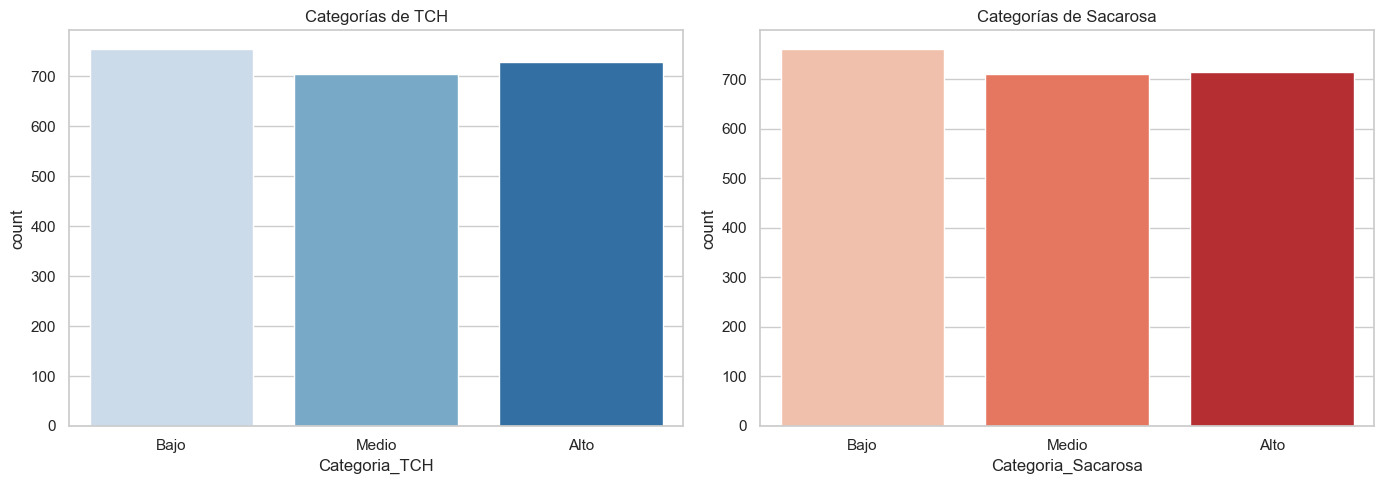

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Categoria_TCH', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[0], palette='Blues')
axes[0].set_title('Categorías de TCH')

sns.countplot(x='Categoria_Sacarosa', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[1], palette='Reds')
axes[1].set_title('Categorías de Sacarosa')

plt.tight_layout()
plt.show()

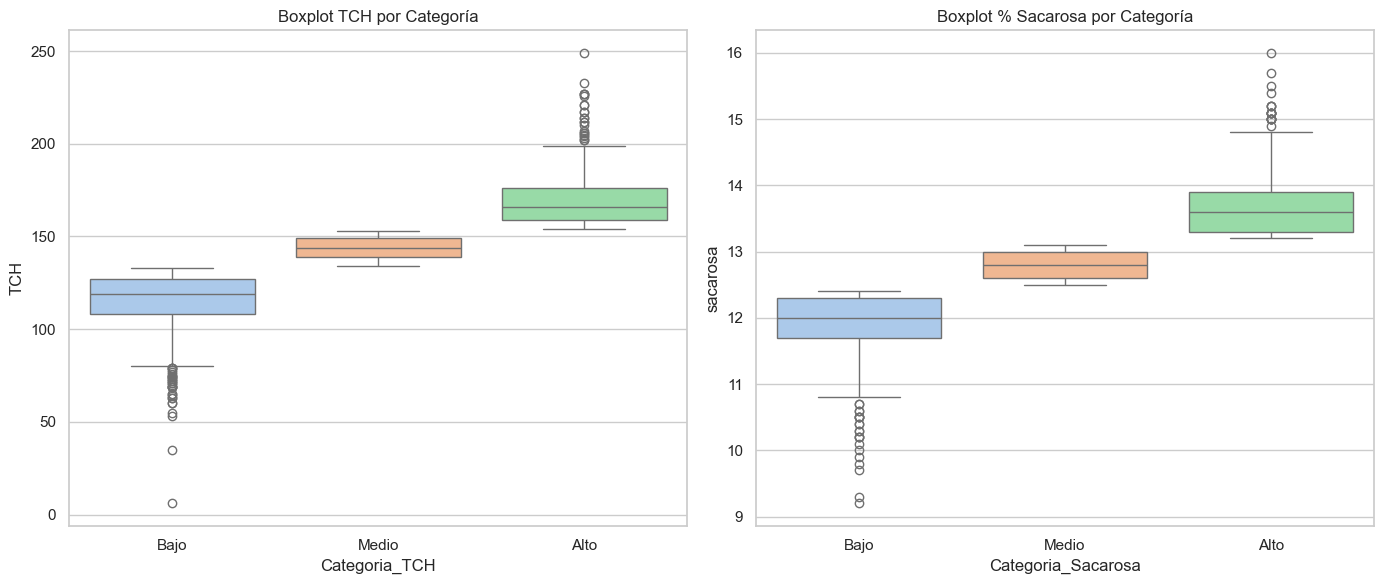

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Categoria_TCH', y='TCH', data=df, order=['Bajo', 'Medio', 'Alto'], palette='pastel', ax=axes[0])
axes[0].set_title('Boxplot TCH por Categoría')

sns.boxplot(x='Categoria_Sacarosa', y='sacarosa', data=df, order=['Bajo', 'Medio', 'Alto'], palette='pastel', ax=axes[1])
axes[1].set_title('Boxplot % Sacarosa por Categoría')

plt.tight_layout()
plt.show()

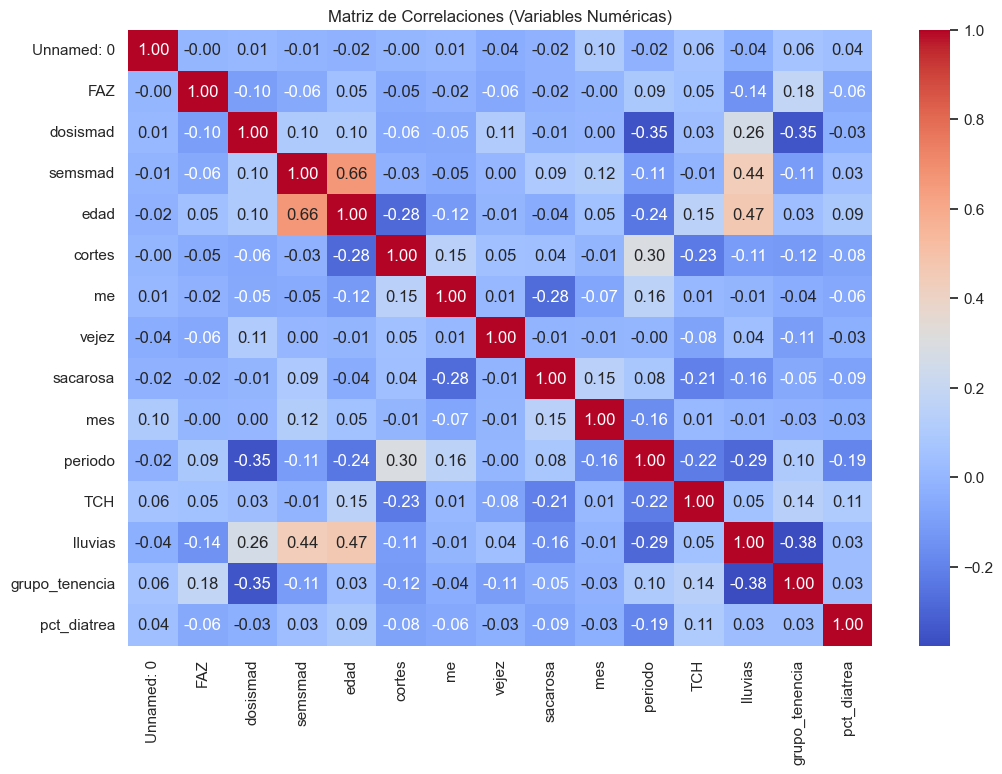

In [22]:
# Solo columnas numéricas para evitar error
num_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlaciones (Variables Numéricas)')
plt.show()

In [69]:
df.to_csv('Datos/BD_IPSA_Clasificada.csv', index=False)
print('Archivo con categorías guardado como BD_IPSA_Clasificada.csv')

Archivo con categorías guardado como BD_IPSA_Clasificada.csv


In [23]:
ipsa_df = pd.read_excel("Datos/BD_IPSA_1940.xlsx")

### Limpieza de la base de datos

In [ ]:
ipsa_df = ipsa_df.drop('Unnamed: 0', axis=1)

In [32]:
null_counts_ipsa = ipsa_df.isnull().sum().sort_values(ascending=False)
null_percentage_ipsa = (null_counts_ipsa / len(ipsa_df)) * 100
ipsa_df_clean = ipsa_df.copy()

In [33]:
# Eliminar columnas redundantes
ipsa_df_clean.drop(columns=['NOME'], inplace=True)


In [34]:
ipsa_df_clean['Eficiencia_riego'] = ipsa_df_clean['lluvias'] / ipsa_df_clean['edad']


In [ ]:
from sklearn.preprocessing import StandardScaler



numeric_cols_ipsa = ['edad', 'dosismad', 'lluvias']
# Escalado
scaler = StandardScaler()
ipsa_df_clean[numeric_cols_ipsa] = scaler.fit_transform(ipsa_df_clean[numeric_cols_ipsa])

### TCH clasificación

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
import numpy as np
import pandas as pd

# --- 1. Crear variable categórica para TCH si no existe ---
if 'Categoria_TCH' not in ipsa_df_clean.columns:
    q_tch = np.percentile(ipsa_df_clean['TCH'], [33.3, 66.6])
    def categorizar_tch(valor):
        if valor <= q_tch[0]:
            return 'Bajo'
        elif valor <= q_tch[1]:
            return 'Medio'
        else:
            return 'Alto'
    ipsa_df_clean['Categoria_TCH'] = ipsa_df_clean['TCH'].apply(categorizar_tch)

# --- 2. Variables predictoras y target ---
y = ipsa_df_clean['Categoria_TCH']
X = ipsa_df_clean.drop(['TCH', 'Categoria_TCH'], axis=1, errors='ignore')

# --- 3. Limpieza robusta ---
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0)
y = y.loc[X.index]

# --- 4. Revisar clases disponibles ---
print("Distribución de clases en y:")
print(y.value_counts())

# --- 5. Columnas numéricas y categóricas ---
numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(include=["category", "object"]).columns

# --- CONVERSIÓN PARA EVITAR ERROR ---
for col in categorical_features:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# --- 6. Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- 7. Pipeline con LogisticRegression (regularización L1 y L2) ---
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", multi_class="ovr"))
])

param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"]
}

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)
search.fit(X_train, y_train)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor accuracy (CV): {search.best_score_:.2f}")

y_pred = search.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.3f   }")

# --- 8. Importancia de variables (coeficientes) ---
feature_names = list(numeric_features)
if len(categorical_features) > 0:
    ohe = search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names += list(cat_names)

coefs = search.best_estimator_.named_steps['classifier'].coef_
for i, clase in enumerate(search.best_estimator_.named_steps['classifier'].classes_):
    print(f"\nImportancia de variables para clase '{clase}':")
    coef_df = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs[i]})
    print(coef_df.sort_values(by='Coeficiente', key=np.abs, ascending=False).head(10))

Distribución de clases en y:
Categoria_TCH
Bajo     754
Alto     728
Medio    705
Name: count, dtype: int64
Mejores parámetros: {'classifier__C': 10, 'classifier__penalty': 'l1'}
Mejor accuracy (CV): 0.47
              precision    recall  f1-score   support

        Alto       0.52      0.58      0.55       219
        Bajo       0.48      0.47      0.48       226
       Medio       0.35      0.31      0.33       212

    accuracy                           0.46       657
   macro avg       0.45      0.46      0.45       657
weighted avg       0.45      0.46      0.45       657

Kappa: 0.187

Importancia de variables para clase 'Alto':
     Variable  Coeficiente
195  TAL_517B     5.567030
199   TAL_519     5.483626
217   TAL_601     5.454209
197   TAL_518     5.398637
190  TAL_507A     5.302452
170    TAL_42     5.039970
69   TAL_019B     5.023529
188  TAL_506A     4.910112
187  TAL_505C     4.880835
72   TAL_025B     4.841841

Importancia de variables para clase 'Bajo':
     Variable 

## Clasificación Sac. caña

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, cohen_kappa_score
import numpy as np
import pandas as pd

# --- 1. Crear variable categórica para sacarosa si no existe ---
if 'Categoria_Sacarosa' not in ipsa_df_clean.columns:
    q_sac = np.percentile(ipsa_df_clean['sacarosa'], [33.3, 66.6])
    def categorizar_sacarosa(valor):
        if valor <= q_sac[0]:
            return 'Bajo'
        elif valor <= q_sac[1]:
            return 'Medio'
        else:
            return 'Alto'
    ipsa_df_clean['Categoria_Sacarosa'] = ipsa_df_clean['sacarosa'].apply(categorizar_sacarosa)

# --- 2. Variables predictoras y target ---
y = ipsa_df_clean['Categoria_Sacarosa']
X = ipsa_df_clean.drop(['sacarosa', 'Categoria_Sacarosa'], axis=1, errors='ignore')

# --- 3. Limpieza robusta ---
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0)
y = y.loc[X.index]

# --- 4. Revisar clases disponibles ---
print("Distribución de clases en y:")
print(y.value_counts())

# --- 5. Columnas numéricas y categóricas ---
numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(include=["category", "object"]).columns

# --- CONVERSIÓN PARA EVITAR ERROR ---
for col in categorical_features:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# --- 6. Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- 7. Pipeline con LogisticRegression (regularización L1 y L2) ---
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", multi_class="ovr"))
])

param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"]
}

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)
search.fit(X_train, y_train)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor accuracy (CV): {search.best_score_:.2f}")

y_pred = search.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.3f}")

# --- 8. Importancia de variables (coeficientes) ---
feature_names = list(numeric_features)
if len(categorical_features) > 0:
    ohe = search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names += list(cat_names)

coefs = search.best_estimator_.named_steps['classifier'].coef_
for i, clase in enumerate(search.best_estimator_.named_steps['classifier'].classes_):
    print(f"\nImportancia de variables para clase '{clase}':")
    coef_df = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs[i]})
    print(coef_df.sort_values(by='Coeficiente', key=np.abs, ascending=False).head(10))

Distribución de clases en y:
Categoria_Sacarosa
Bajo     761
Alto     716
Medio    710
Name: count, dtype: int64
Mejores parámetros: {'classifier__C': 1, 'classifier__penalty': 'l1'}
Mejor accuracy (CV): 0.49
              precision    recall  f1-score   support

        Alto       0.46      0.57      0.51       215
        Bajo       0.51      0.58      0.54       229
       Medio       0.43      0.27      0.33       213

    accuracy                           0.47       657
   macro avg       0.47      0.47      0.46       657
weighted avg       0.47      0.47      0.46       657

Kappa: 0.210

Importancia de variables para clase 'Alto':
     Variable  Coeficiente
224    TAL_71     2.258616
119    TAL_26     1.704090
28   TAL_003B    -1.234576
55   TAL_011A     1.082083
27   TAL_003A    -1.059420
15   TAL_001B     0.828144
98     TAL_14     0.781608
236     TAL_8    -0.764097
39   TAL_005C    -0.750794
225   TAL_710     0.702282

Importancia de variables para clase 'Bajo':
     Varia

### REGRESIÓN TCH 

MSE: 603.48
RMSE: 24.57
R²: 0.0822
MAE: 19.30


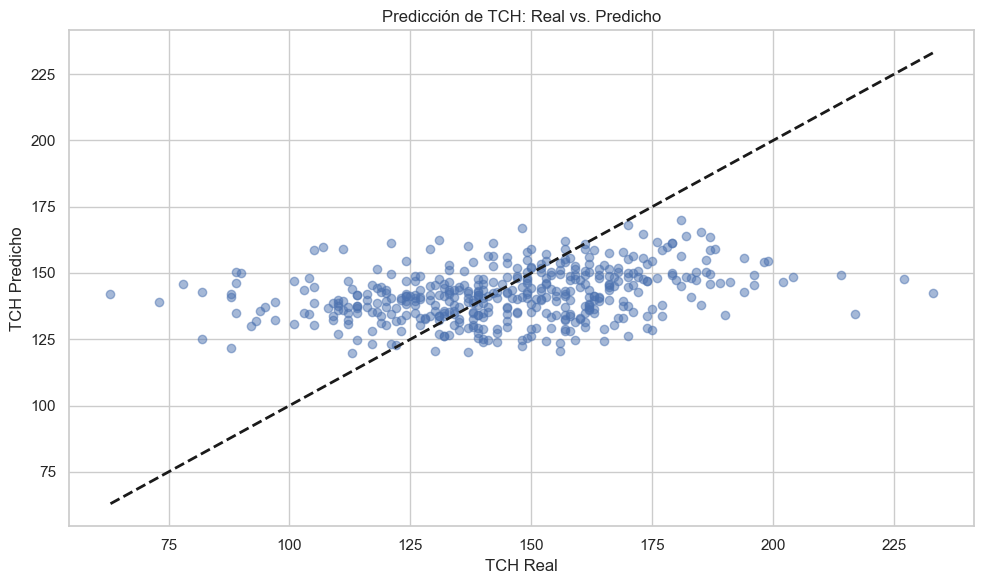

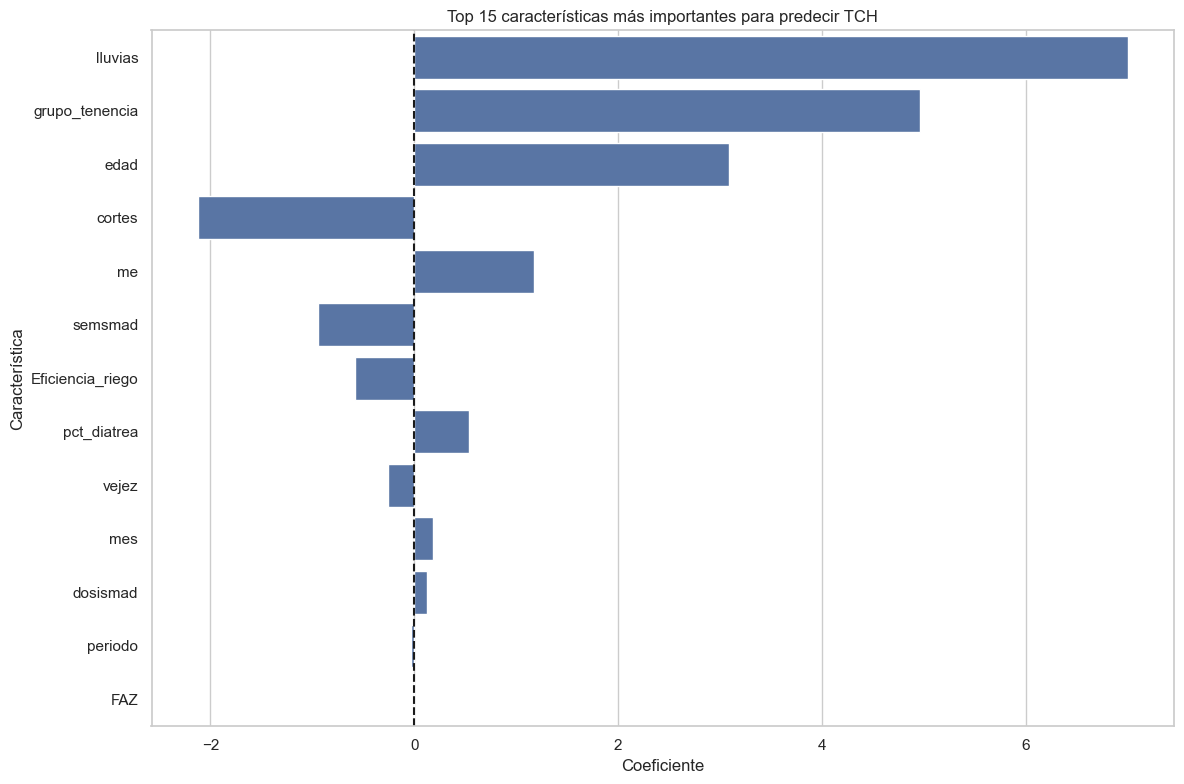

MSE entrenamiento: 582.89, MSE prueba: 603.48
R² entrenamiento: 0.1274, R² prueba: 0.0822
R² validación cruzada (5-fold): 0.0662 ± 0.0670


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

X = ipsa_df_clean.drop(['TCH', 'sacarosa', 'TonUltCorte', 'categoria_Sacarosa', 'Produccion'], axis=1, errors='ignore')
non_numeric_cols = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype == 'datetime64[ns]']
X = X.drop(non_numeric_cols, axis=1)
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

y = ipsa_df_clean['TCH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('TCH Real')
plt.ylabel('TCH Predicho')
plt.title('Predicción de TCH: Real vs. Predicho')
plt.grid(True)
plt.tight_layout()
plt.show()

coefficients = pd.DataFrame({'Característica': X.columns, 'Coeficiente': model.coef_})
top_features = coefficients.reindex(coefficients['Coeficiente'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Característica', data=top_features.head(15))
plt.title('Top 15 características más importantes para predecir TCH')
plt.axvline(x=0, color='k', linestyle='--')
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"MSE entrenamiento: {train_mse:.2f}, MSE prueba: {mse:.2f}")
print(f"R² entrenamiento: {train_r2:.4f}, R² prueba: {r2:.4f}")

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print(f"R² validación cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


MSE: 0.67
RMSE: 0.82
R²: 0.1250
MAE: 0.62


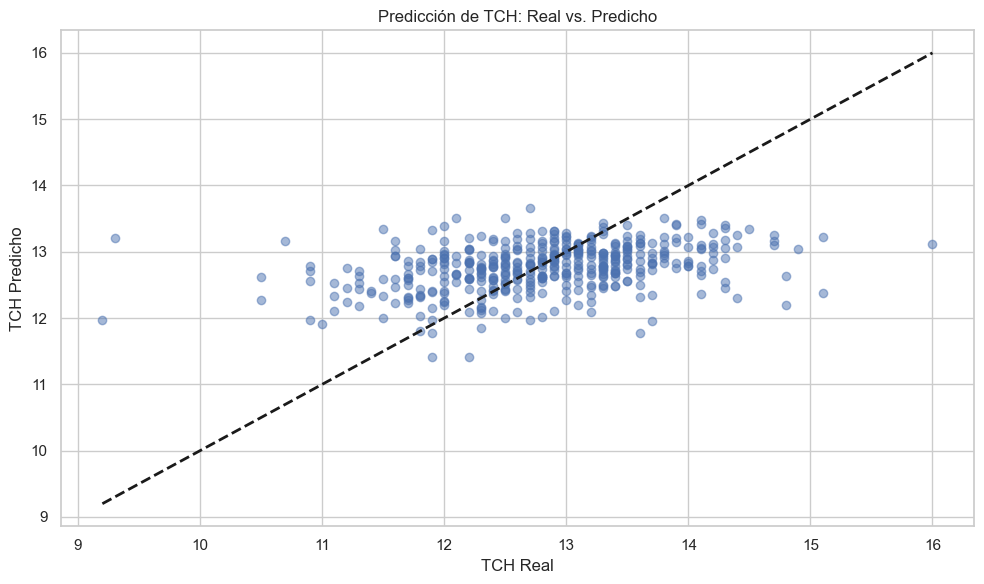

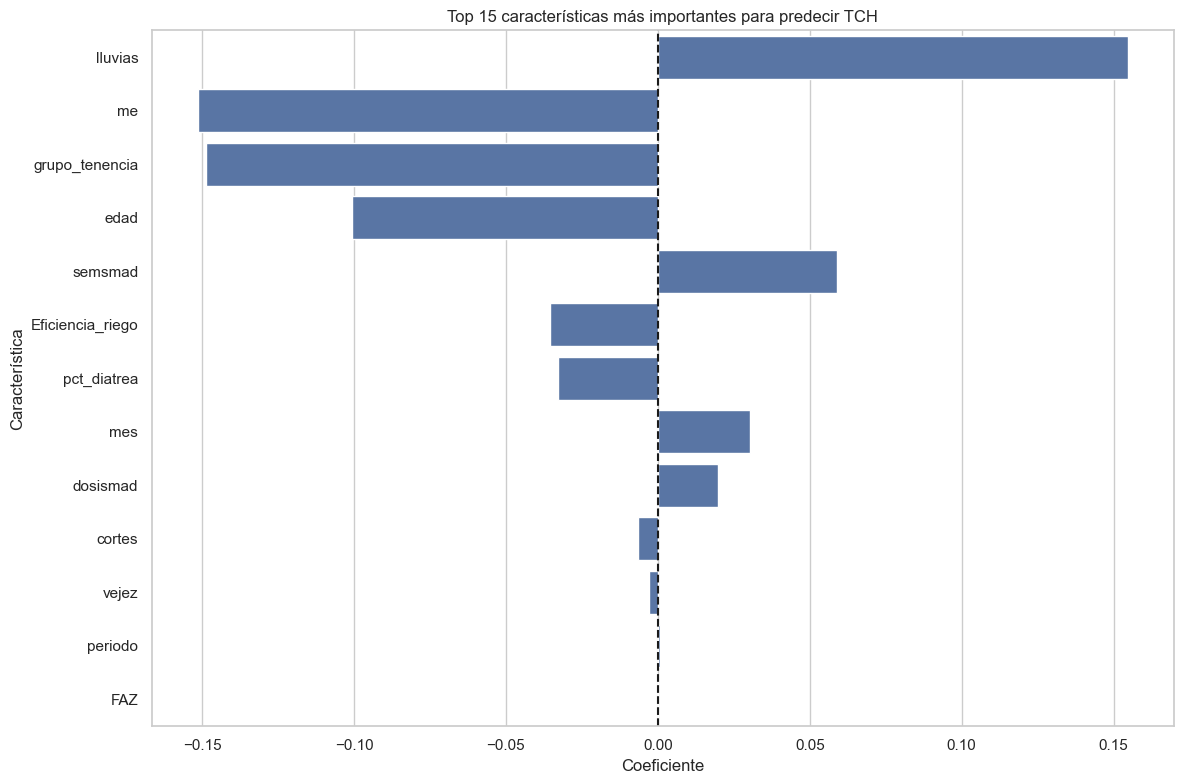

MSE entrenamiento: 0.58, MSE prueba: 0.67
R² entrenamiento: 0.1971, R² prueba: 0.1250
R² validación cruzada (5-fold): 0.1418 ± 0.0477


In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

X = ipsa_df_clean.drop(['TCH', 'sacarosa', 'TonUltCorte', 'categoria_Sacarosa', 'Produccion'], axis=1, errors='ignore')
non_numeric_cols = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype == 'datetime64[ns]']
X = X.drop(non_numeric_cols, axis=1)
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

y = ipsa_df_clean['sacarosa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('TCH Real')
plt.ylabel('TCH Predicho')
plt.title('Predicción de TCH: Real vs. Predicho')
plt.grid(True)
plt.tight_layout()
plt.show()

coefficients = pd.DataFrame({'Característica': X.columns, 'Coeficiente': model.coef_})
top_features = coefficients.reindex(coefficients['Coeficiente'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Característica', data=top_features.head(15))
plt.title('Top 15 características más importantes para predecir TCH')
plt.axvline(x=0, color='k', linestyle='--')
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"MSE entrenamiento: {train_mse:.2f}, MSE prueba: {mse:.2f}")
print(f"R² entrenamiento: {train_r2:.4f}, R² prueba: {r2:.4f}")

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print(f"R² validación cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
